# Covers Lecture 9 Content

In [ ]:
# Import necessary libraries
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

## Using Seaborn

In [2]:
# Load the "tips" dataset
tips = sns.load_dataset("tips")
print(tips)


     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

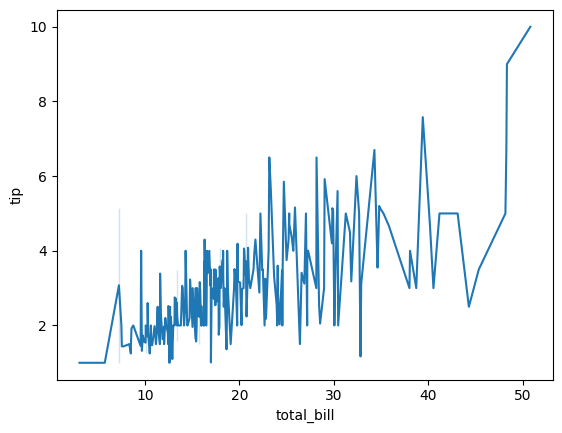

In [3]:
# Create a line plot using seaborn
sns.lineplot(
    data=tips,        # choose dataset
    x='total_bill',   # define x variable
    y='tip'           # define y variable
)


In [4]:
# Set the style
sns.set_style('whitegrid')


[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

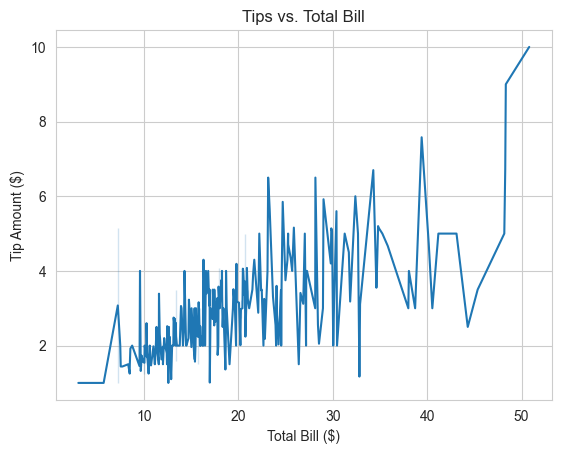

In [5]:
# Customize the plot with titles and labels
tipgraph = sns.lineplot(data=tips, x='total_bill', y='tip')

tipgraph.set(
    title='Tips vs. Total Bill',
    xlabel='Total Bill ($)',
    ylabel='Tip Amount ($)'
)


[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

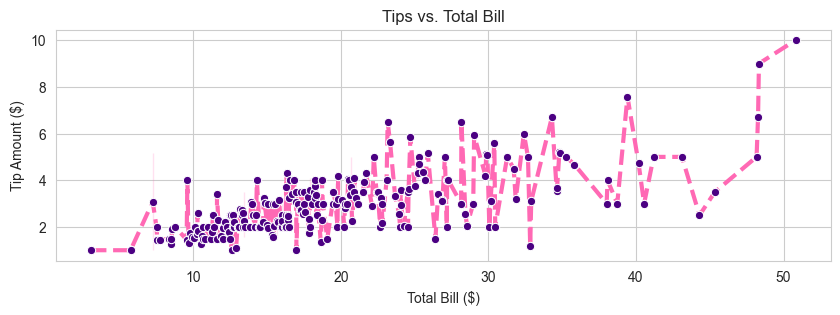

In [ ]:
# Set figure size
fig = plt.subplots(figsize=(10, 3))

# Customize line and marker styles
tipgraph = sns.lineplot(
    data=tips,
    x='total_bill',
    y='tip',
    color='hotpink',
    linestyle='--',
    linewidth=3,
    marker='o',
    markerfacecolor='indigo'
)

# Title and labels
tipgraph.set(
    title='Tips vs. Total Bill',
    xlabel='Total Bill ($)',
    ylabel='Tip Amount ($)'
)

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

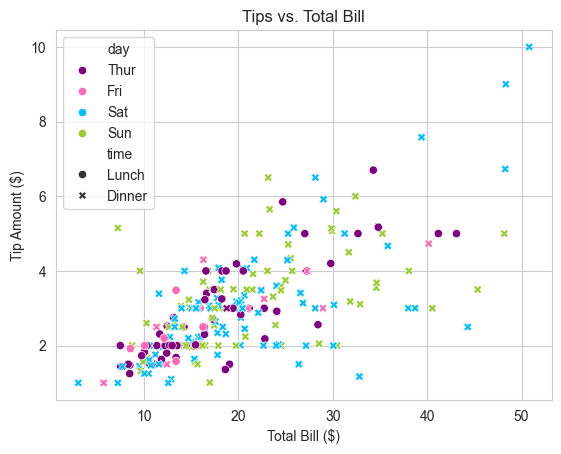

In [ ]:
# Scatter plot with multiple variables
tipgraph = sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    style='time',
    hue='day',
    palette=['purple', 'hotpink', 'deepskyblue', 'yellowgreen']
)

tipgraph.set(
    title='Tips vs. Total Bill',
    xlabel='Total Bill ($)',
    ylabel='Tip Amount ($)'
)


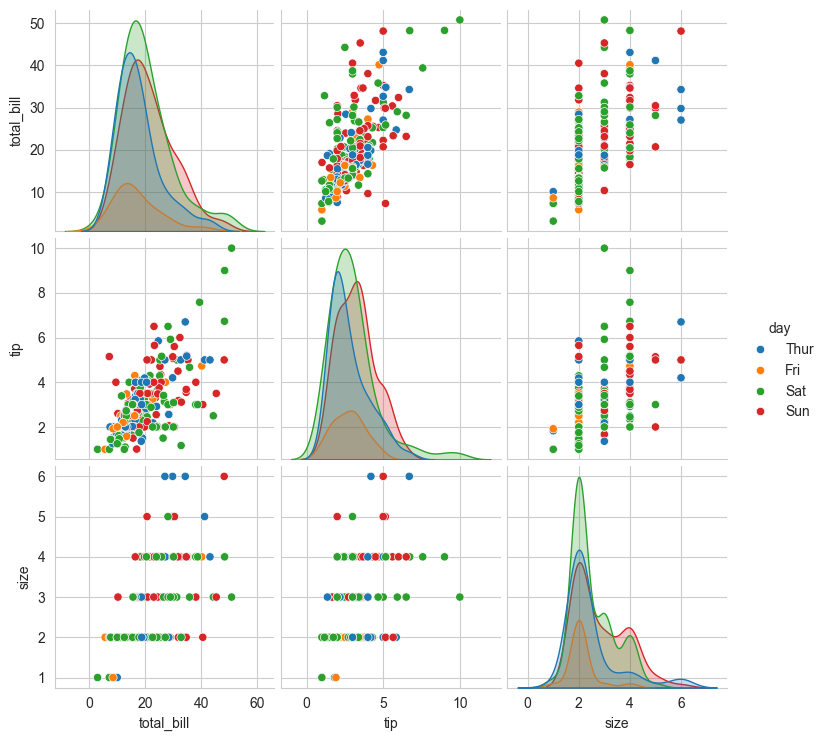

In [ ]:
# Pairplot to visualize relationships
sns.pairplot(
    data=tips,
    hue='day'
)


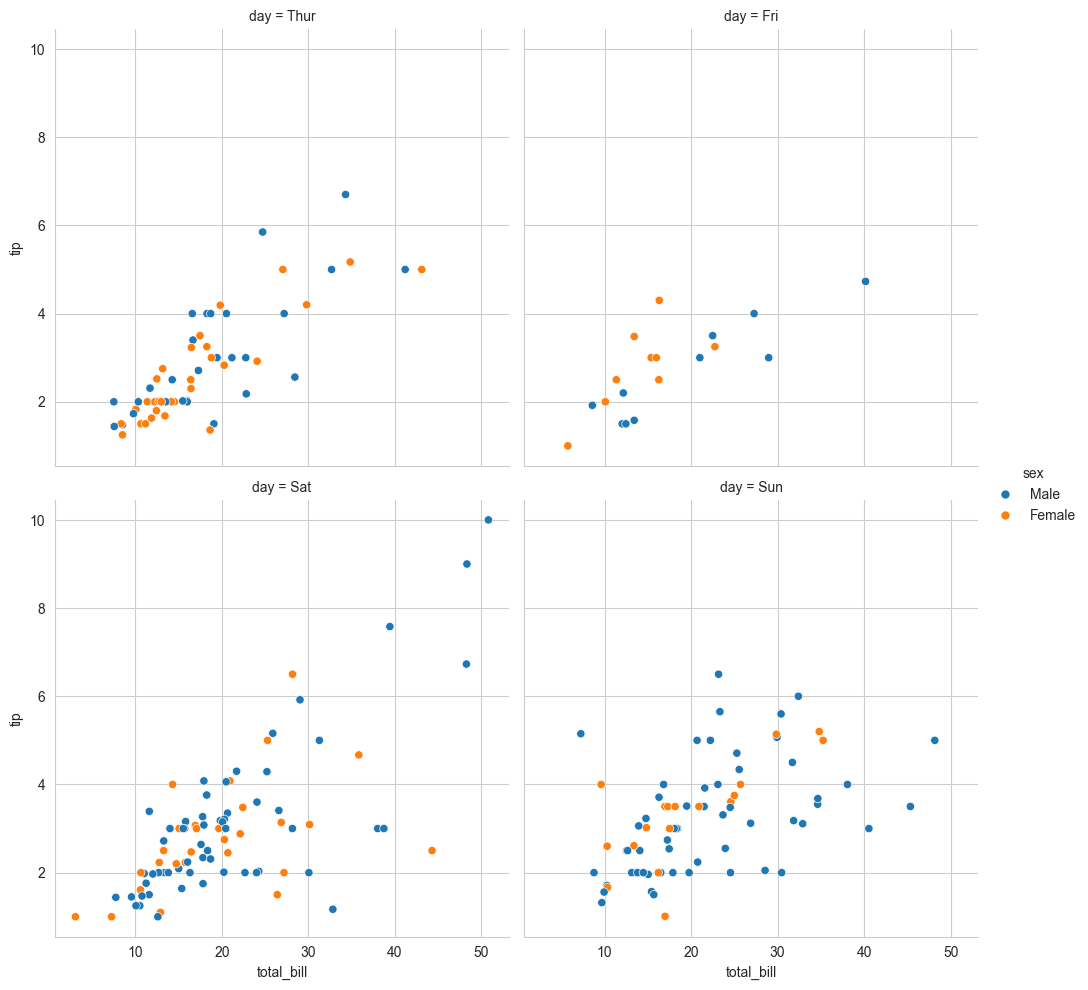

In [ ]:
# Explore multicategorial relationships
daysplot = sns.relplot(
    data=tips, # choose dataset
    x="total_bill", # define x variable
    y="tip", # define y variable
    hue="sex", # define colour by a third variable (sex)
    col="day", # create separate plots for each day
    kind="scatter", # define the type of plot
    col_wrap=2 # wrap the plots around after 2 plots
)


## Case Study and Activities
Please see the assignment-1.md file in the participation/ folder for responses to the activities on slides 23 and 32 in Lecture 9.

## Using Plotly

In [ ]:
# Plotly setup
import plotly.graph_objects as go  

x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])


In [ ]:
# Create an interactive bar graph
graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))

# Add titles
graph.update_layout(
    title="Pirate Scores",
    xaxis_title="Pirates",
    yaxis_title="Score"
)

graph.show()

In [ ]:
# Export the graph as an HTML file

graph.write_html("C:\\Users\\adani\\Downloads\\pirategraph.html")

In [ ]:
# Create interactive scatter plot

graph = go.Figure()
graph.add_trace(go.Scatter(
    x=x1,
    y=y1,
    mode='markers',  # points for scatter plot
    marker=dict(
        size=15,             # point size
        color='hotpink',     # point colour
        opacity=1,           # point transparency
        line=dict(width=5, color='purple')  # point outline
    )
))

graph.update_layout(
    title='Interactive Pirate Plot',
    xaxis_title='Pirates',
    yaxis_title='Scores',
    width=500,
    height=500
)


## Other Stuff

In [ ]:
# Word Cloud Corpus of Movie Quotes

from wordcloud import WordCloud

df = pd.read_csv(
    "https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
    on_bad_lines='skip'
)
df


,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

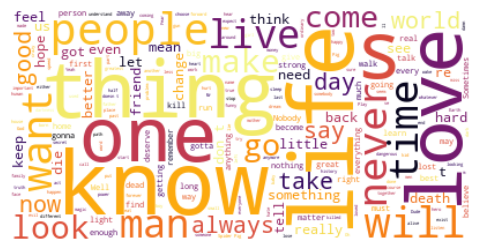

In [ ]:
# Create and display the word cloud

text = " ".join(each for each in df.quote)

wordcloud = WordCloud(
    background_color="white",
    colormap='inferno'
).generate(text)

fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis("off")


In [20]:
# Venn Diagram import and setup

from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])


c:\Users\adani\Downloads\Projects\visualization\visualization\visualization-env\Lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



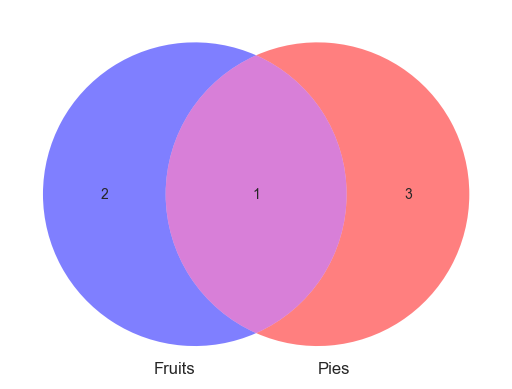

In [ ]:
# Show basic Venn Diagram

diagram = venn2_unweighted(
    [A, B],
    set_labels=('Fruits', 'Pies'),
    set_colors=("blue", "red"),
    alpha=0.5
)
plt.show()

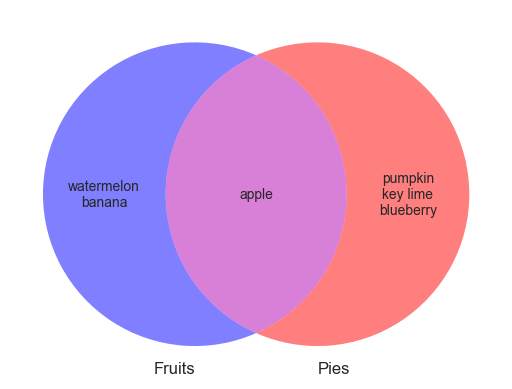

In [ ]:
# Customize Venn Diagram labels

diagram = venn2_unweighted(
    [A, B],
    set_labels=('Fruits', 'Pies'),
    set_colors=("blue", "red"),
    alpha=0.5
)

diagram.get_label_by_id("10").set_text("\n".join(A - B))
diagram.get_label_by_id("11").set_text("\n".join(A & B))
diagram.get_label_by_id("01").set_text("\n".join(B - A))

plt.show()